In [1]:
import numpy as np
from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
from config import setup_model_and_geometry
from config import PATH_DATA_DSUB, TMAX, OUTPUT_DIRS

In [ ]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DSUB)

dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.01 s


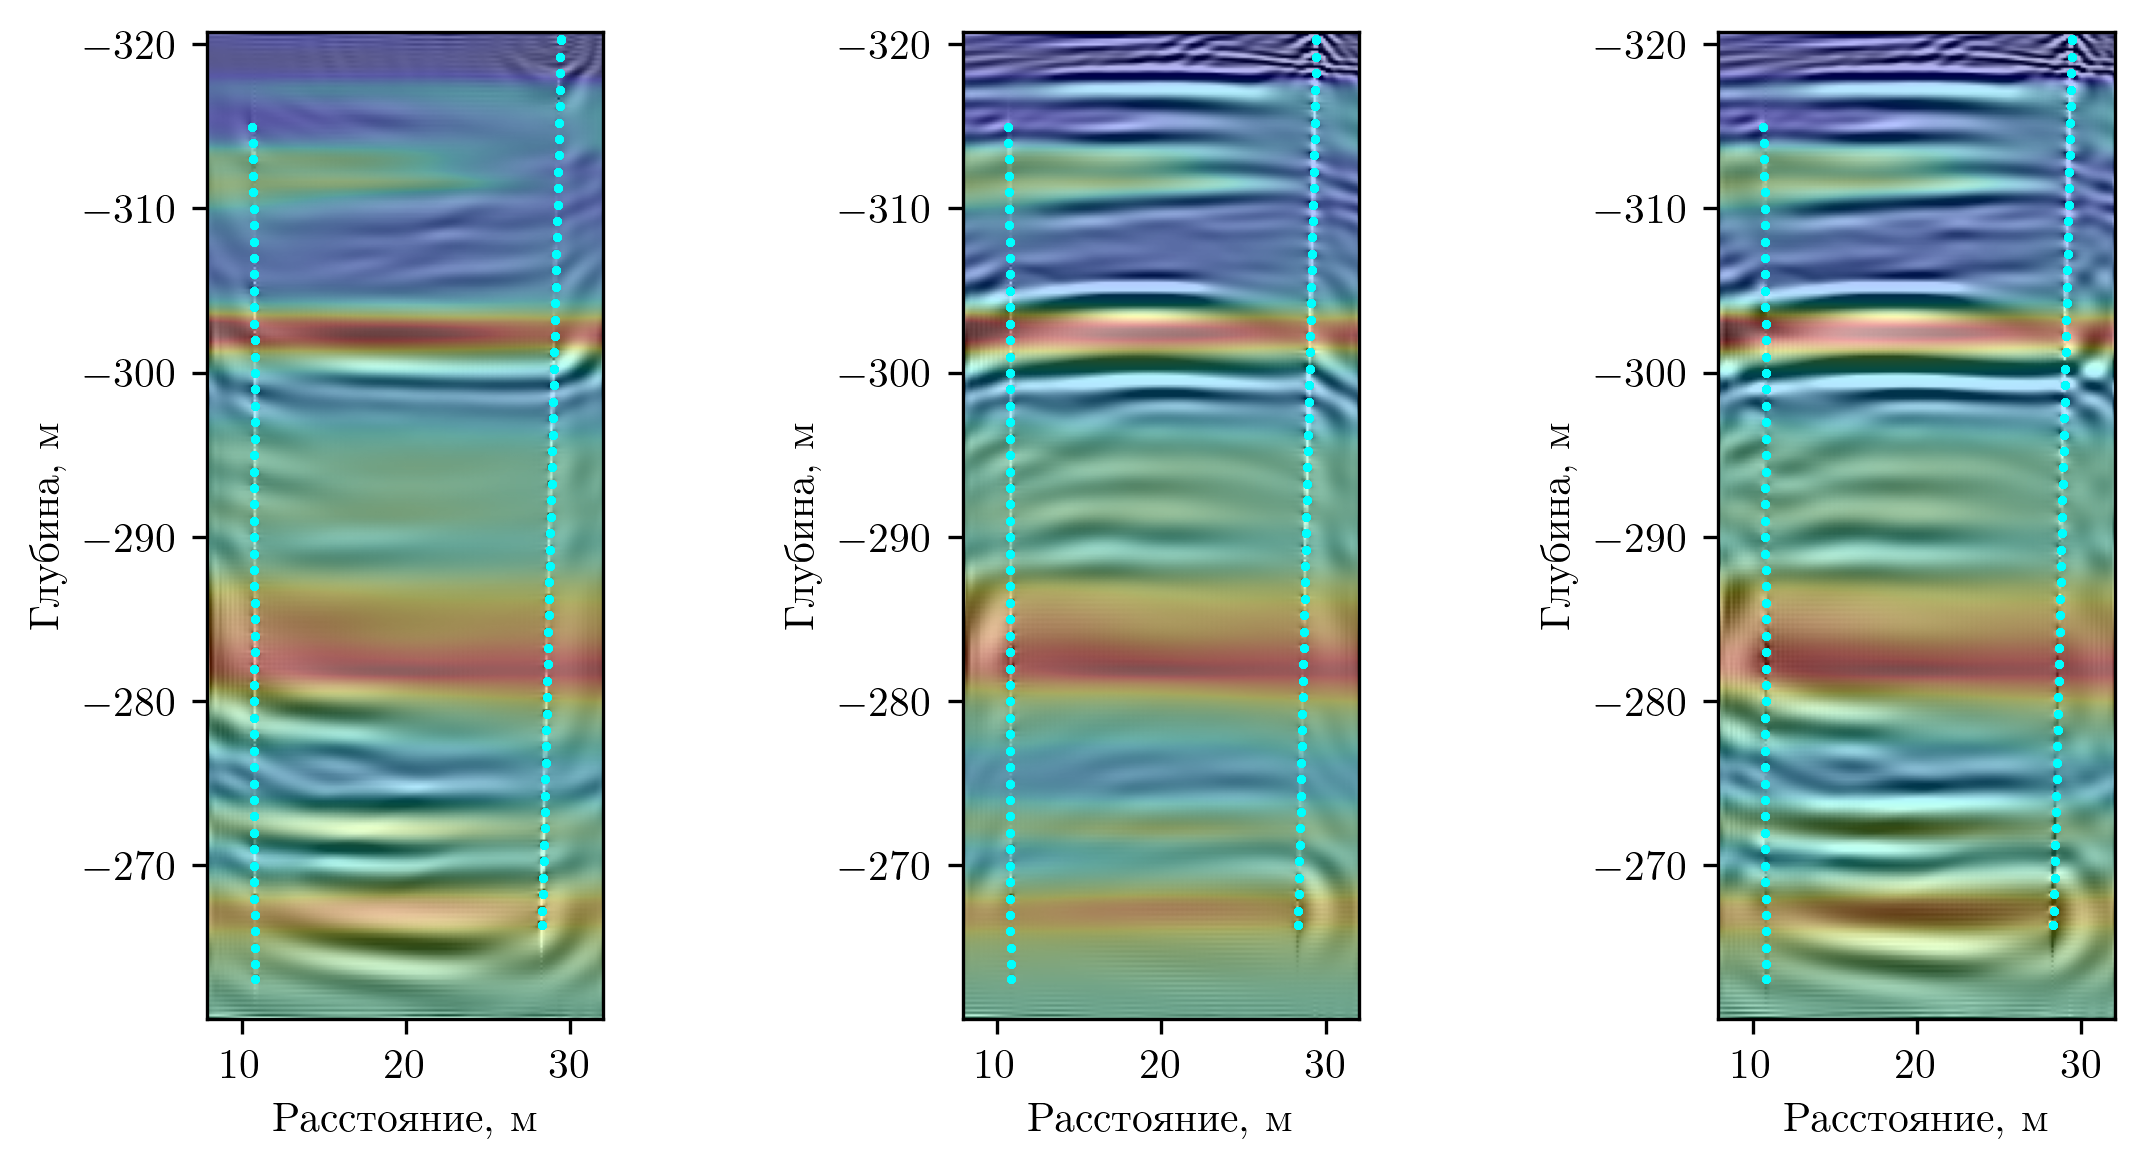

In [4]:
from config import NBL
grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_u_0.npy")
grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_d_0.npy")
extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]

fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d0, 0.9), np.quantile(grad_u0, 0.9)])
imag0 = grad_u0-grad_d0
for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
    h=ax.imshow(laplace(gr.T),
                vmin=-glmax/3, vmax=glmax/3,
                cmap='gray', extent=extent)
    hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=extent)
    ax.scatter(dataset.x_coords, dataset.elevations, s=1, c='cyan')
    ax.scatter(dataset.opposite_x, dataset.opposite_elev, s=1, c='cyan')

    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

plt.tight_layout()
plt.show()

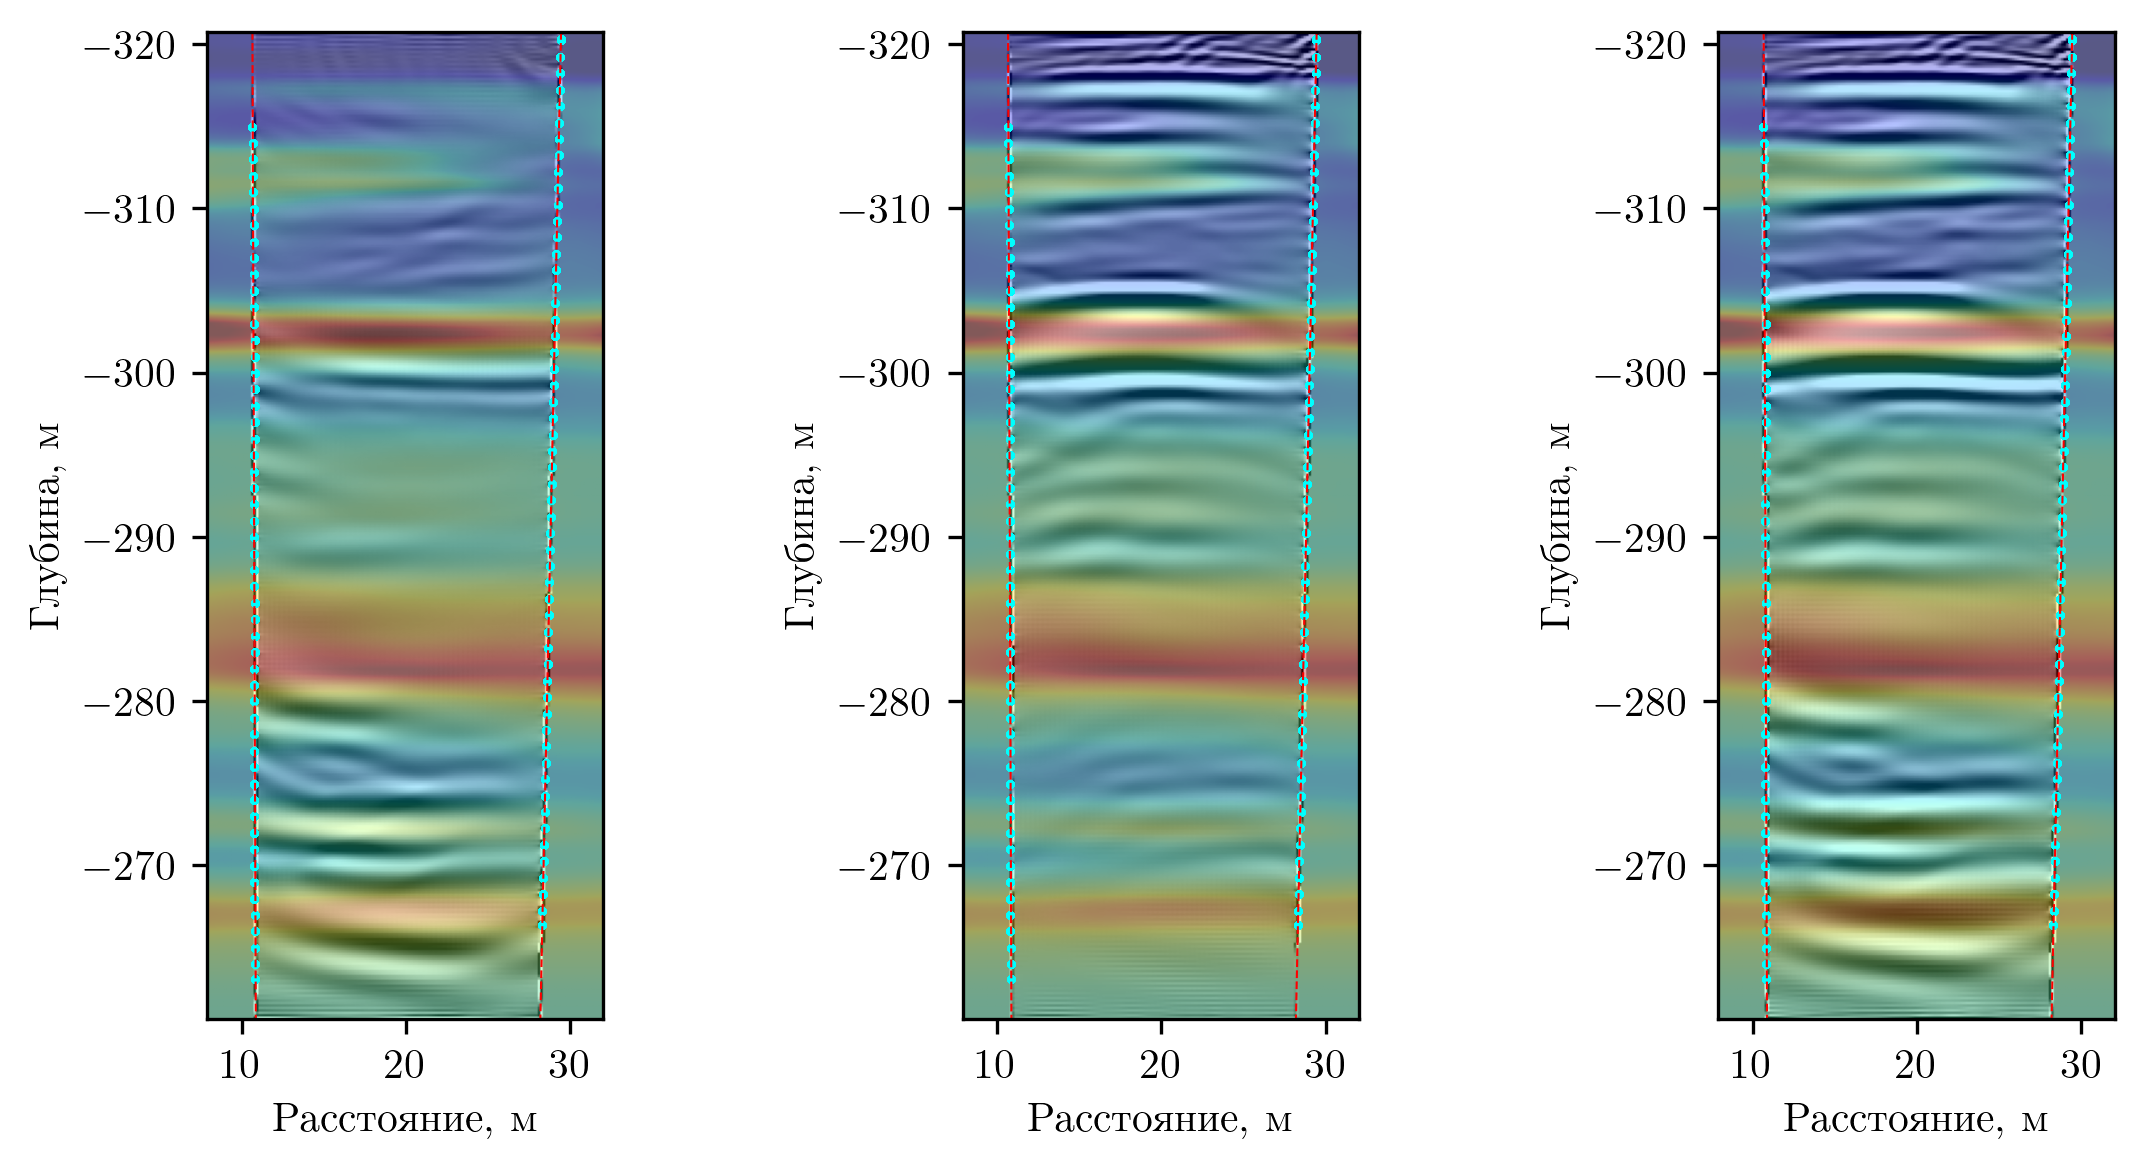

In [12]:
from config import NBL
import numpy as np
from scipy import stats
from scipy.ndimage import laplace

# Load data
grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_u_0.npy")
grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_d_0.npy")
extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]

# Perform linear regression for both wells
# Well 1 (dataset.x_coords vs dataset.elevations)
slope1, intercept1, _, _, _ = stats.linregress(dataset.x_coords, dataset.elevations)
# Well 2 (dataset.opposite_x vs dataset.opposite_elev)
slope2, intercept2, _, _, _ = stats.linregress(dataset.opposite_x, dataset.opposite_elev)

# Create meshgrid for masking
x = np.linspace(extent[0], extent[1], grad_u0.shape[0])
z = np.linspace(extent[3], extent[2], grad_u0.shape[1])
xx, zz = np.meshgrid(x, z, indexing='ij')

# Create masks
# For well1 (left boundary): points should be to the right of well1
mask1 = xx > (zz - intercept1)/slope1 if slope1 != 0 else xx > intercept1
# For well2 (right boundary): points should be to the left of well2
mask2 = xx < (zz - intercept2)/slope2 if slope2 != 0 else xx < intercept2
# Combined mask (between wells)
between_wells_mask = mask1 & mask2

# Apply masks to gradients and image
grad_d0_masked = grad_d0 * between_wells_mask
grad_u0_masked = grad_u0 * between_wells_mask
imag0_masked = (grad_u0 - grad_d0) * between_wells_mask

fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d0, 0.9), np.quantile(grad_u0, 0.9)])

for gr, ax in zip([grad_d0_masked, grad_u0_masked, imag0_masked], axs):
    h = ax.imshow(laplace(gr.T),
                vmin=-glmax/3, vmax=glmax/3,
                cmap='gray', extent=extent)
    hh = ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, 
                 cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=extent)
    
    # Plot well trajectories
    ax.scatter(dataset.x_coords, dataset.elevations, s=1, c='cyan')
    ax.scatter(dataset.opposite_x, dataset.opposite_elev, s=1, c='cyan')
    
    # Plot regression lines for visualization
    z_vals = np.array([extent[3], extent[2]])  # top and bottom of the plot
    ax.plot((z_vals - intercept1)/slope1, z_vals, 'r--', linewidth=0.5)  # Well1 regression
    ax.plot((z_vals - intercept2)/slope2, z_vals, 'r--', linewidth=0.5)  # Well2 regression
    
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

plt.tight_layout()
plt.show()

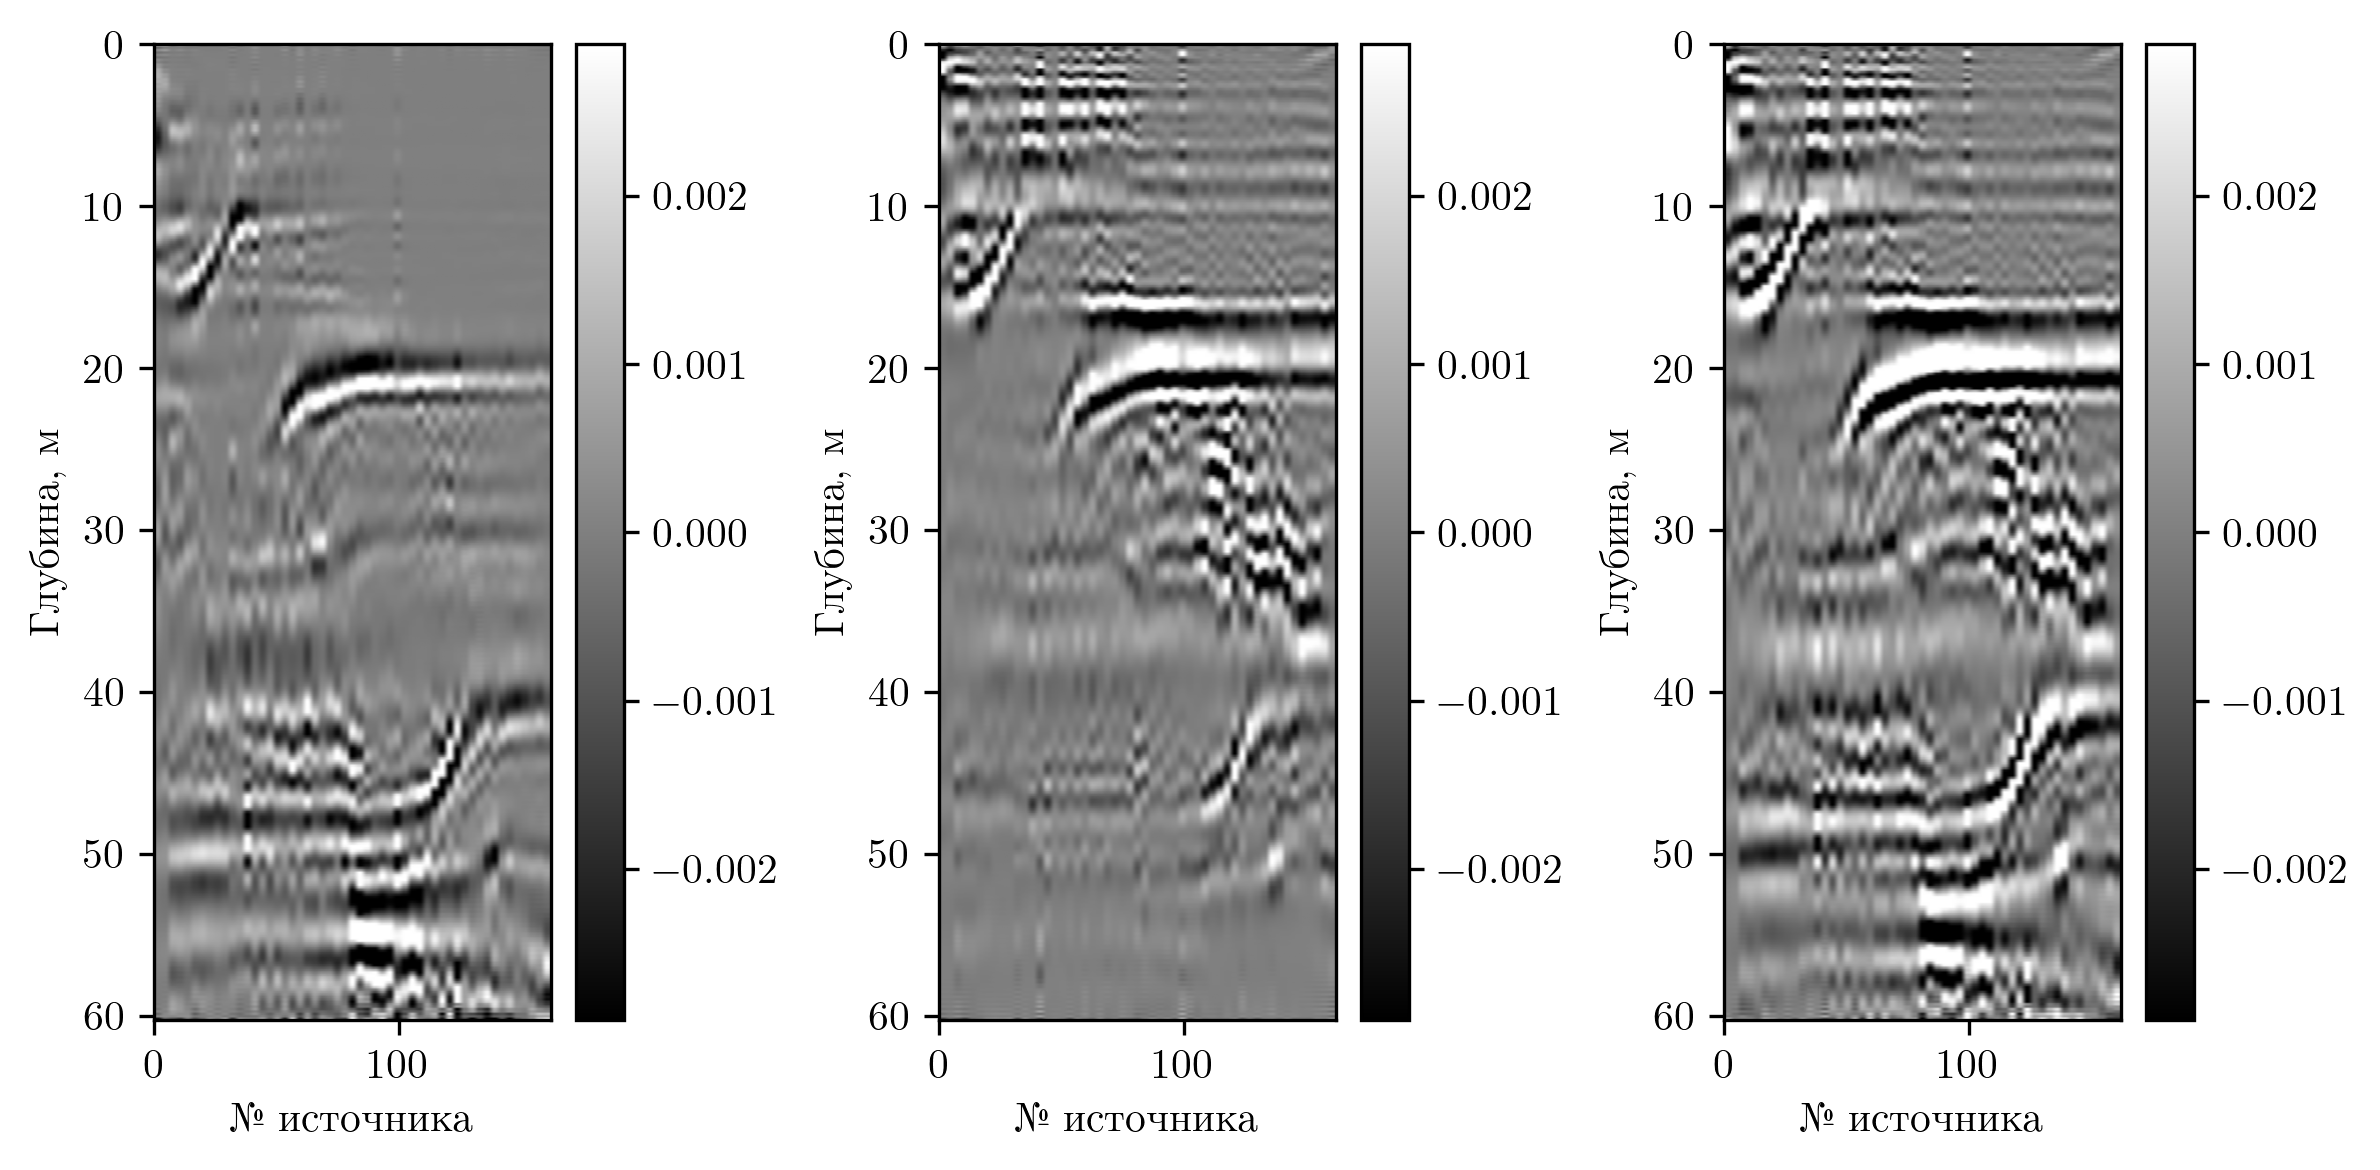

In [78]:
all_grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/all_grad_u_0.npy")
all_grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/all_grad_d_0.npy")
for i in range(all_grad_u0.shape[0]):
    all_grad_u0[i] /= np.linalg.norm(all_grad_u0[i])
    all_grad_d0[i] /= np.linalg.norm(all_grad_d0[i])

IDX = all_grad_u0.shape[1]//2 - 0*all_grad_u0.shape[1]//5
fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(all_grad_u0, 0.99), np.quantile(all_grad_d0, 0.99)])
all_imag0 = all_grad_u0-all_grad_d0
for gr, ax in zip([all_grad_d0, all_grad_u0, all_imag0], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(-np.diff(gaussian_filter(gr.T, sigma=0), axis=0, n=1), cmap='gray', vmin=-glmax/2.5*3e3, vmax=glmax/2.5*3e3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])

    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(laplace(gaussian_filter(gr.T, sigma=0.9)), vmin=-glmax/3, vmax=glmax/3, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(np.diff(uniform_filter(gr.T, size=[5, 5]), axis=0, n=2), vmin=-glmax/10, vmax=glmax/10, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])

    h=ax.imshow(np.diff(gr[:, IDX, :].T, axis=0, n=1), vmin=-glmax/4, vmax=glmax/4, cmap='gray', extent=[0, all_grad_u0.shape[1], all_grad_u0.shape[-1]*0.03*5, 0], aspect='auto')
    # h=ax.imshow(laplace(gr[:, IDX, :].T), vmin=-glmax/4, vmax=glmax/4, cmap='gray', extent=[0, all_grad_u0.shape[1], all_grad_u0.shape[-1]*0.03*5, 0], aspect='auto')

    ax.set_xlabel("№ источника")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

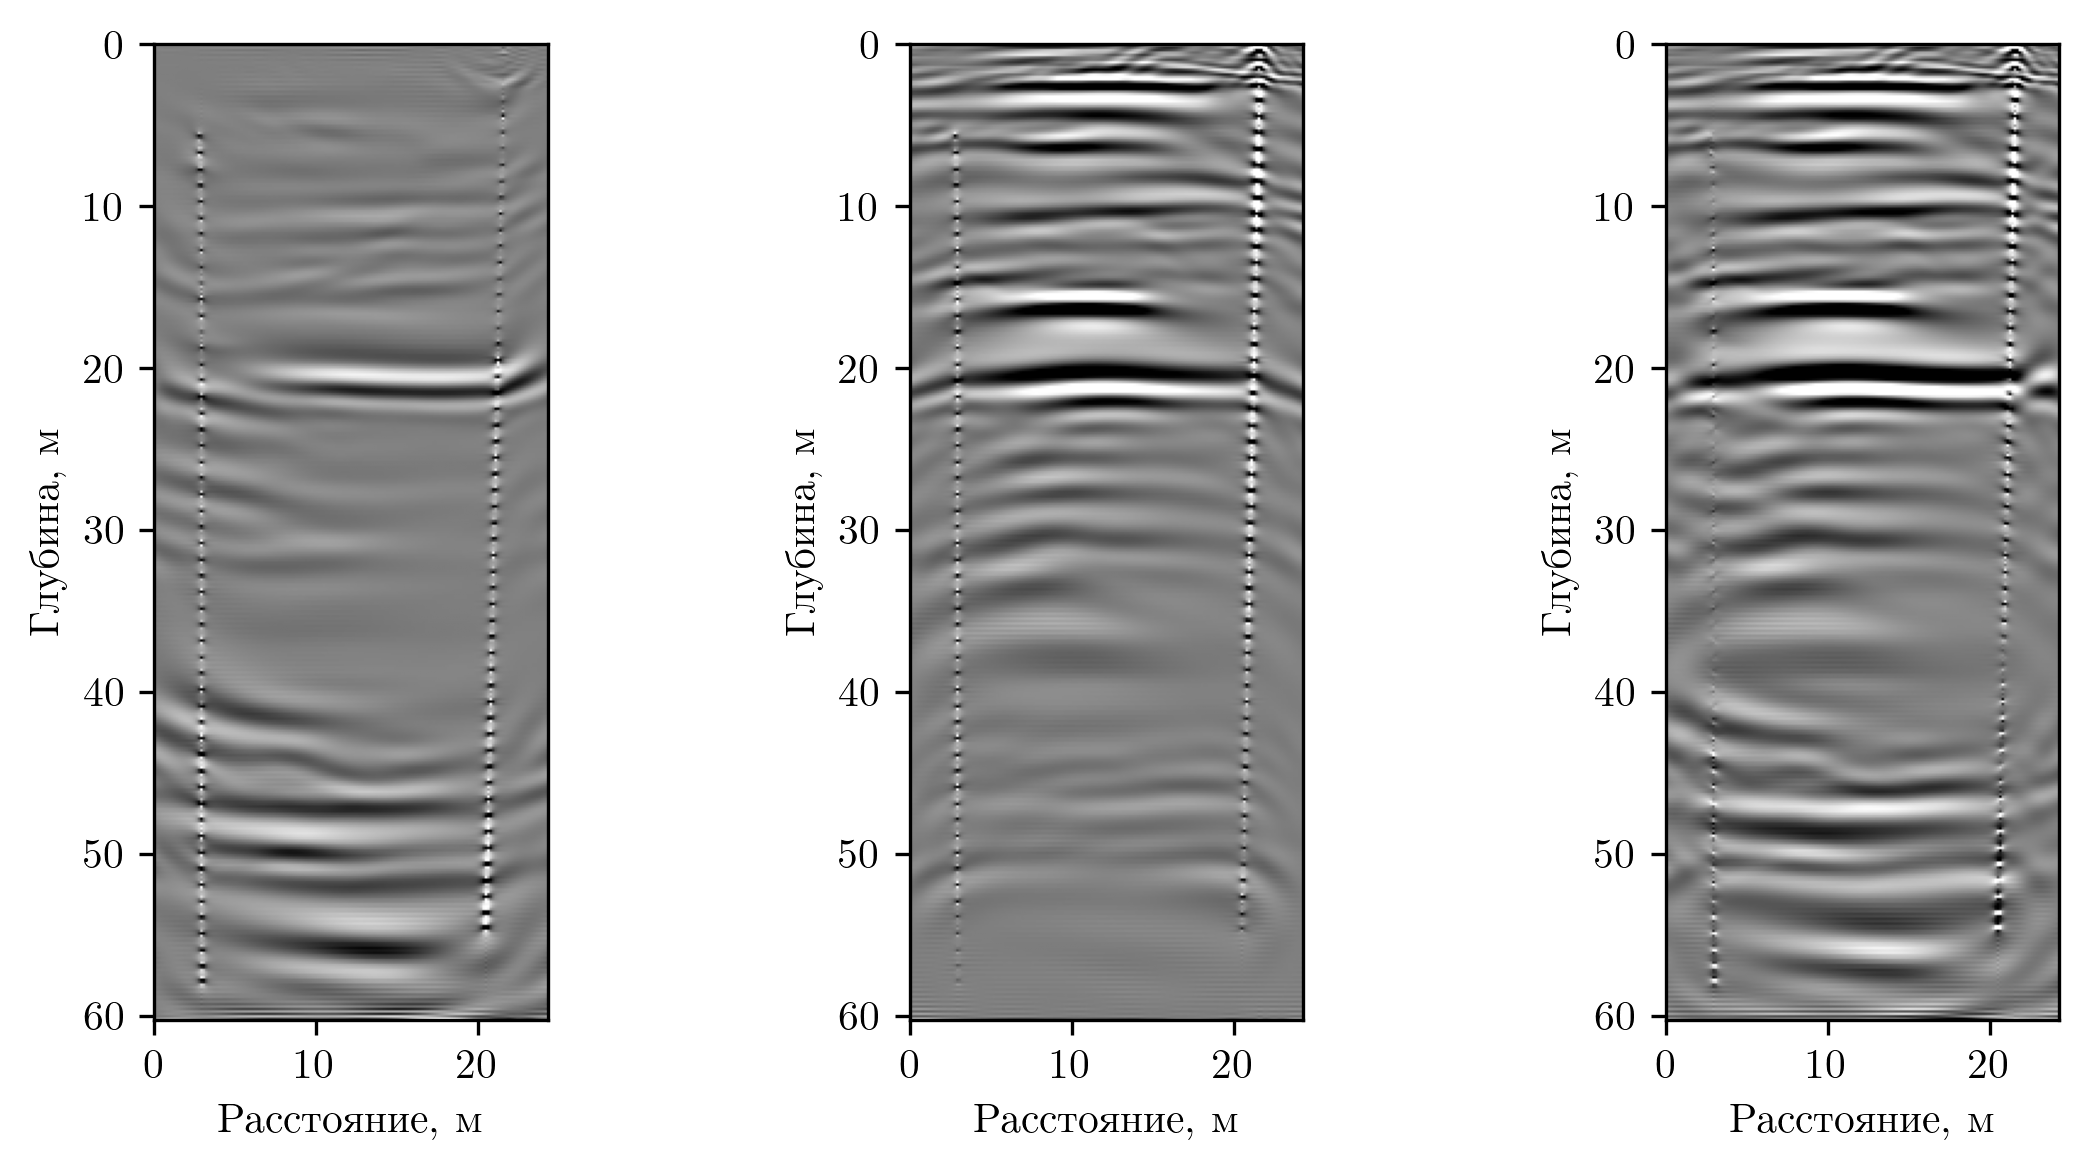

In [80]:
grad_d0 = np.mean(all_grad_d0, axis=0)
grad_u0 = np.mean(all_grad_u0, axis=0)

fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d0, 0.9), np.quantile(grad_u0, 0.9)])
imag0 = grad_u0-grad_d0
for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
    h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/3, vmax=glmax/3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    # h=ax.imshow(-np.diff(gaussian_filter(gr.T, sigma=0), axis=0, n=1), cmap='gray', vmin=-glmax/2.5*3e3, vmax=glmax/2.5*3e3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])

    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(laplace(gaussian_filter(gr.T, sigma=0.9)), vmin=-glmax/3, vmax=glmax/3, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(np.diff(uniform_filter(gr.T, size=[5, 5]), axis=0, n=2), vmin=-glmax/10, vmax=glmax/10, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])

    # h=ax.imshow(laplace(gr.T),
                # vmin=-glmax/3, vmax=glmax/3,
                # cmap='gray', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    # hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    # fig.colorbar(h)



plt.tight_layout()
plt.show()